<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-cancer-patients-2015-24-ml?scriptVersionId=236594347" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-cancer-patients-2015-2024/global_cancer_patients_2015_2024.csv


## Title:
Global Cancer Patients (2015–2024)

## Description:
A dataset tracking cancer patient statistics worldwide from 2015 to 2024, covering trends, demographics, and regional distributions.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/global-cancer-patients-2015-2024/global_cancer_patients_2015_2024.csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [4]:
df.tail()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54
49999,PT0049999,22,Male,Pakistan,2023,5.1,9.8,3.2,0.0,0.7,Liver,Stage 0,64023.82,7.4,3.76


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [6]:
df.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


In [7]:
df.isnull().sum()

Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(50000, 15)

In [10]:
df.dtypes

Patient_ID                object
Age                        int64
Gender                    object
Country_Region            object
Year                       int64
Genetic_Risk             float64
Air_Pollution            float64
Alcohol_Use              float64
Smoking                  float64
Obesity_Level            float64
Cancer_Type               object
Cancer_Stage              object
Treatment_Cost_USD       float64
Survival_Years           float64
Target_Severity_Score    float64
dtype: object

In [11]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

## Data visualizations

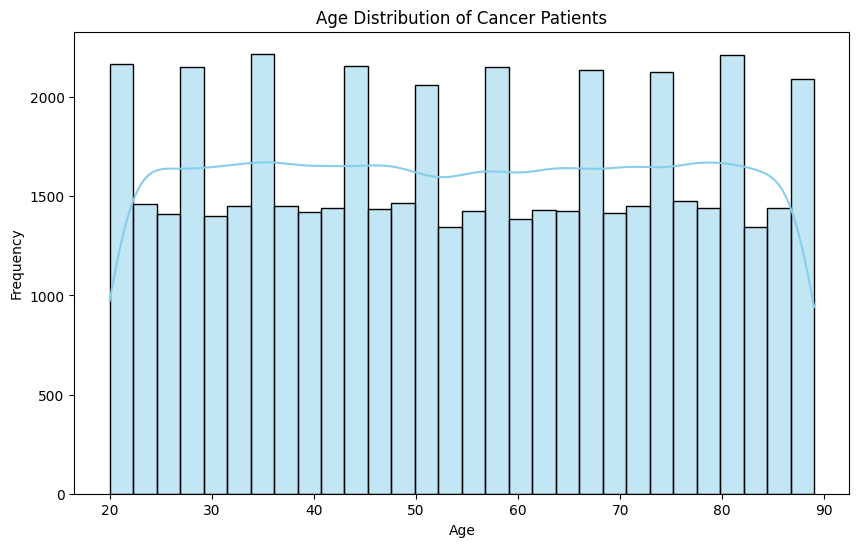

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Cancer Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

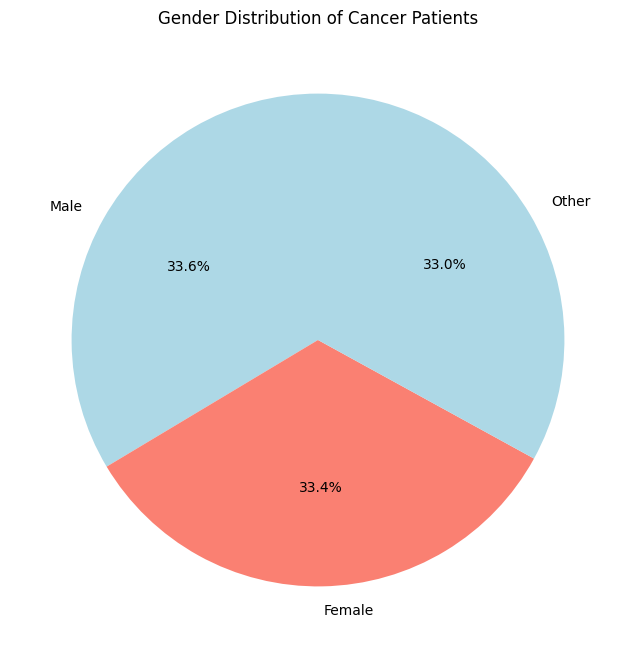

In [13]:
# Pie chart for Gender distribution
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 8))
gender_counts.plot.pie(autopct='%1.1f%%', colors=['lightblue', 'salmon'], startangle=90)
plt.title('Gender Distribution of Cancer Patients')
plt.ylabel('')
plt.show()


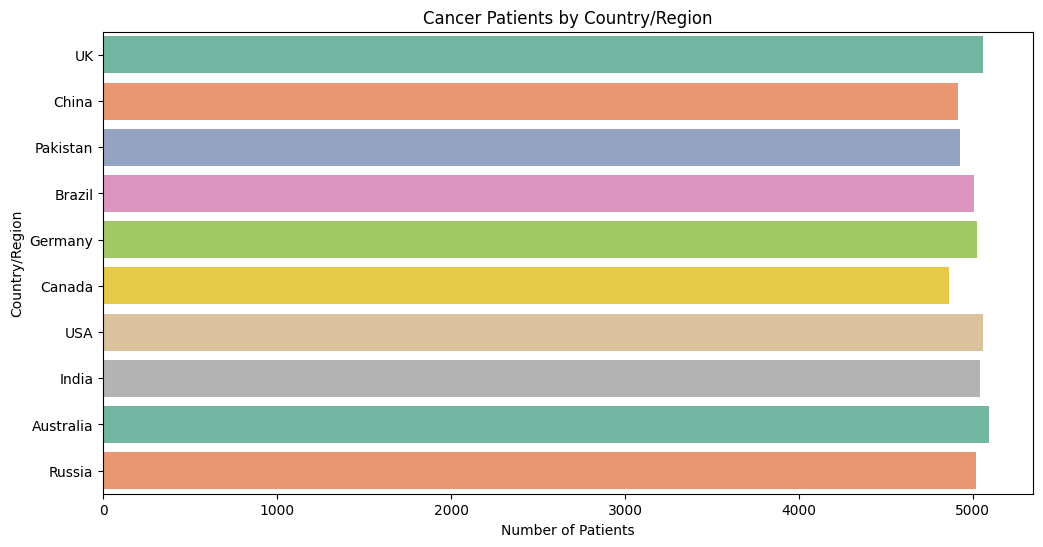

In [14]:
# Bar plot for Country/Region distribution
plt.figure(figsize=(12, 6))
sns.countplot(y='Country_Region', data=df, palette='Set2')
plt.title('Cancer Patients by Country/Region')
plt.xlabel('Number of Patients')
plt.ylabel('Country/Region')
plt.show()


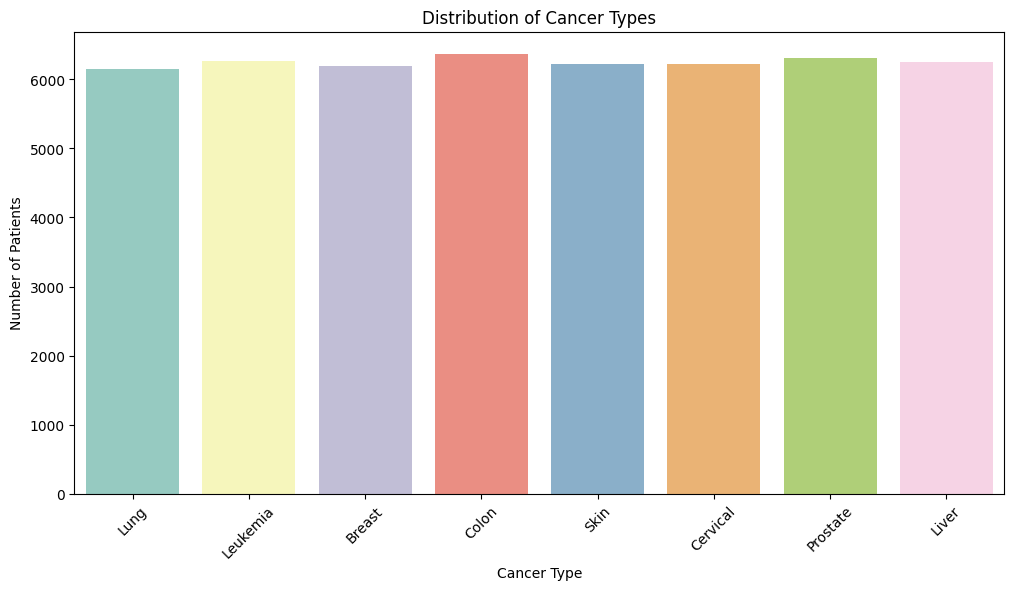

In [15]:
# Bar plot for Cancer Type distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='Cancer_Type', data=df, palette='Set3')
plt.title('Distribution of Cancer Types')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()


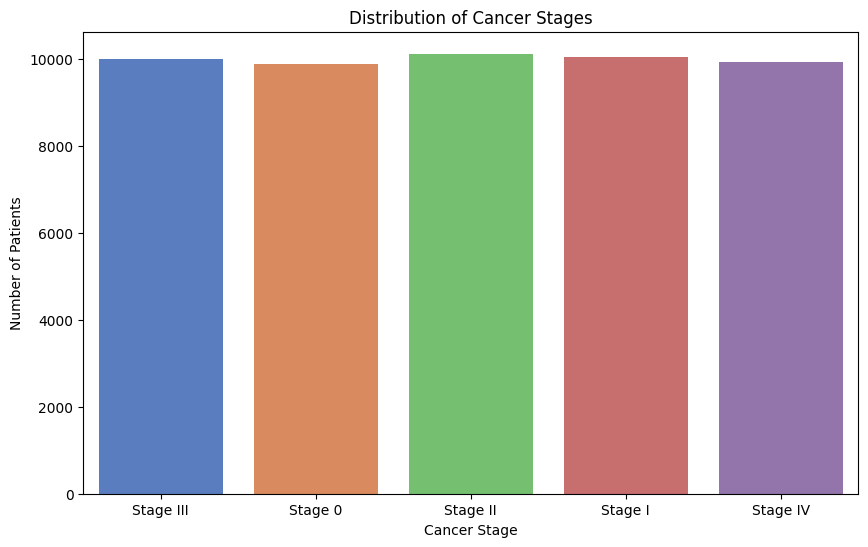

In [16]:
# Bar plot for Cancer Stage distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Cancer_Stage', data=df, palette='muted')
plt.title('Distribution of Cancer Stages')
plt.xlabel('Cancer Stage')
plt.ylabel('Number of Patients')
plt.show()


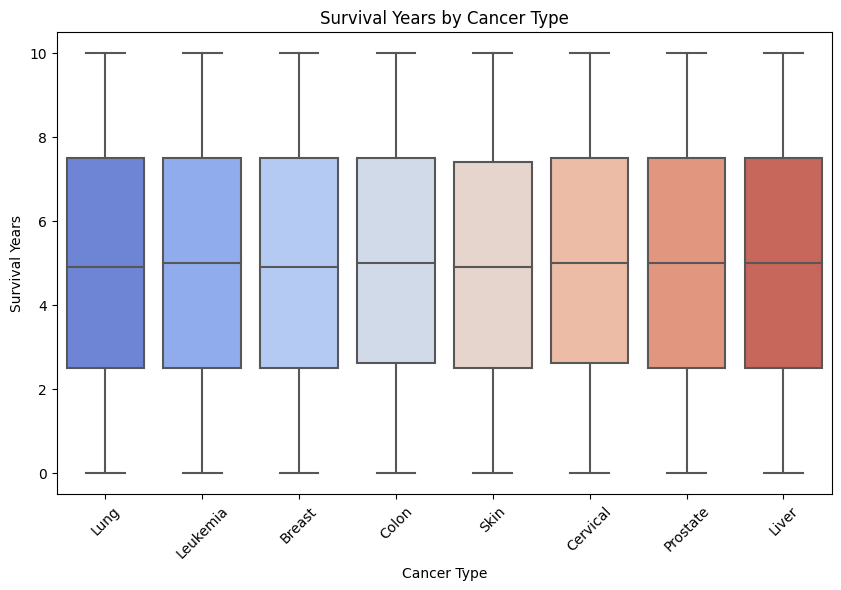

In [17]:
# Boxplot for Survival Years
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cancer_Type', y='Survival_Years', data=df, palette='coolwarm')
plt.title('Survival Years by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Survival Years')
plt.xticks(rotation=45)
plt.show()


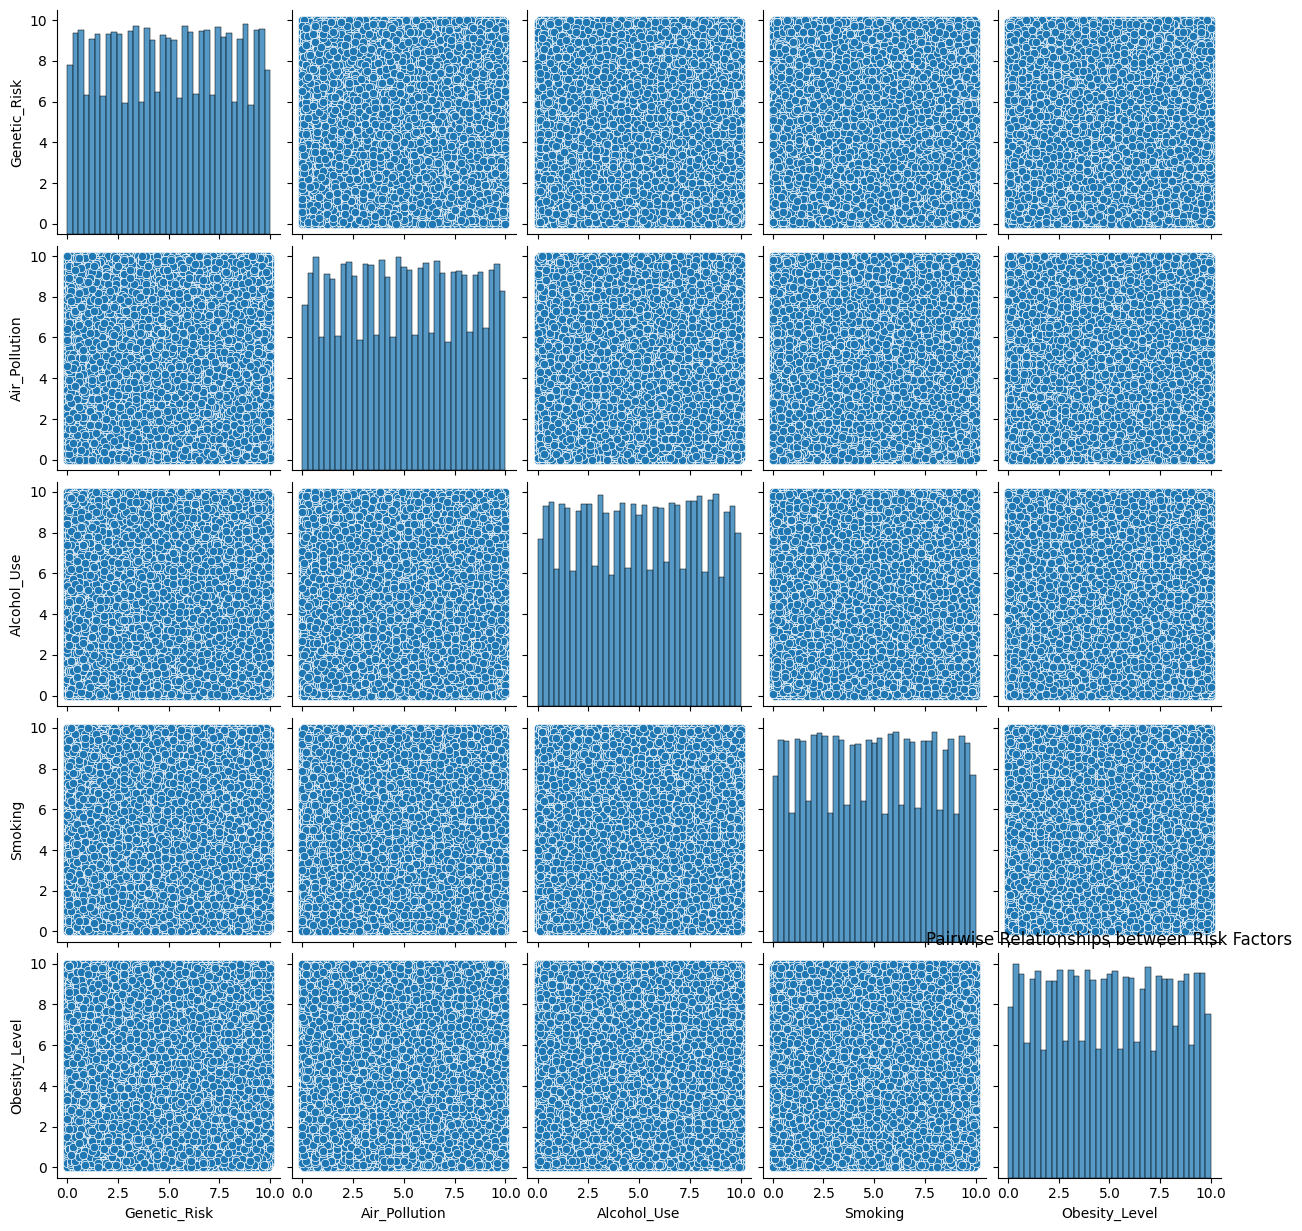

In [18]:
# Pairplot to visualize relationships between genetic risk and other factors
sns.pairplot(df[['Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']])
plt.title('Pairwise Relationships between Risk Factors')
plt.show()


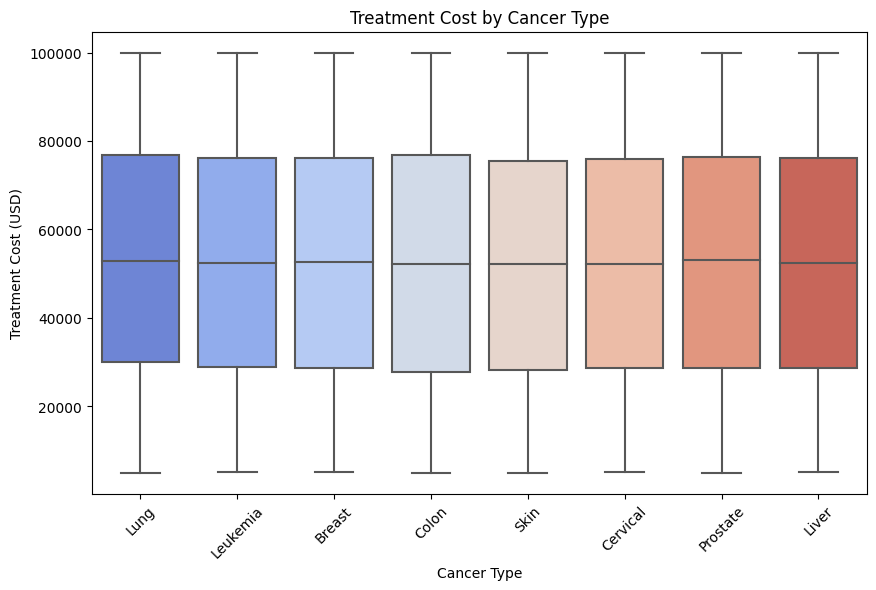

In [19]:
# Boxplot for Treatment Cost by Cancer Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cancer_Type', y='Treatment_Cost_USD', data=df, palette='coolwarm')
plt.title('Treatment Cost by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Treatment Cost (USD)')
plt.xticks(rotation=45)
plt.show()


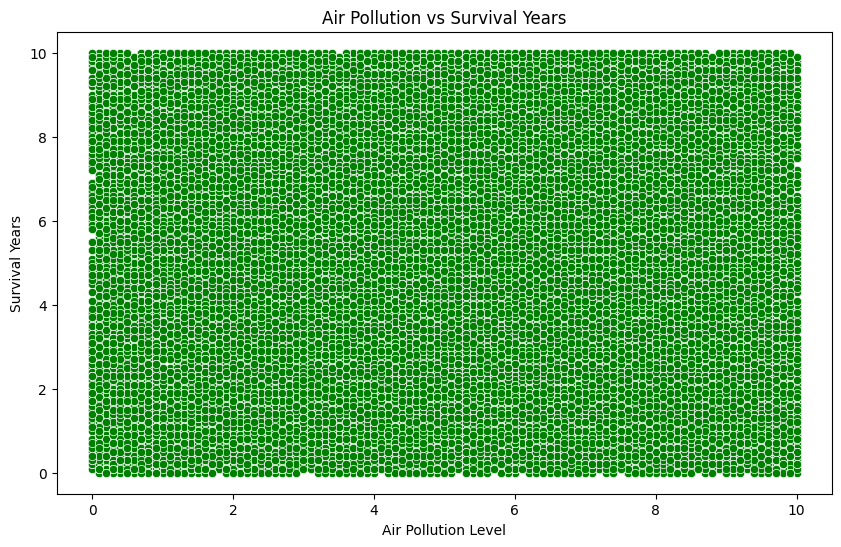

In [20]:
# Scatter plot for Air Pollution vs Survival Years
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Air_Pollution', y='Survival_Years', data=df, color='green')
plt.title('Air Pollution vs Survival Years')
plt.xlabel('Air Pollution Level')
plt.ylabel('Survival Years')
plt.show()


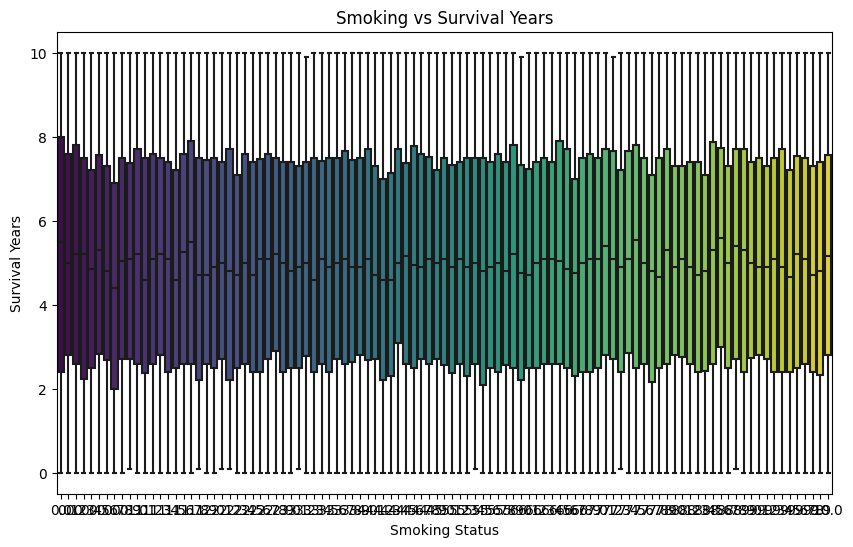

In [21]:
# Boxplot for Smoking vs Survival Years
plt.figure(figsize=(10, 6))
sns.boxplot(x='Smoking', y='Survival_Years', data=df, palette='viridis')
plt.title('Smoking vs Survival Years')
plt.xlabel('Smoking Status')
plt.ylabel('Survival Years')
plt.show()


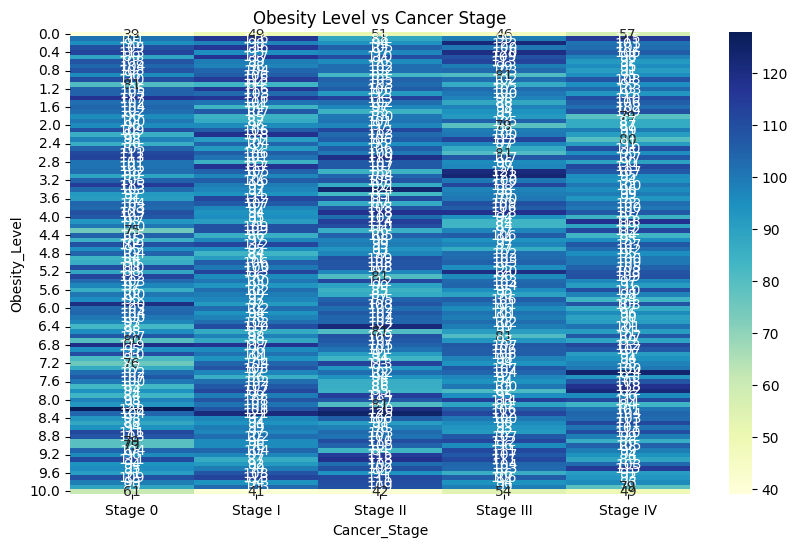

In [22]:
# Heatmap for Obesity Level and Cancer Stage correlation
obesity_cancer_stage = df.groupby(['Obesity_Level', 'Cancer_Stage']).size().unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(obesity_cancer_stage, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Obesity Level vs Cancer Stage')
plt.show()


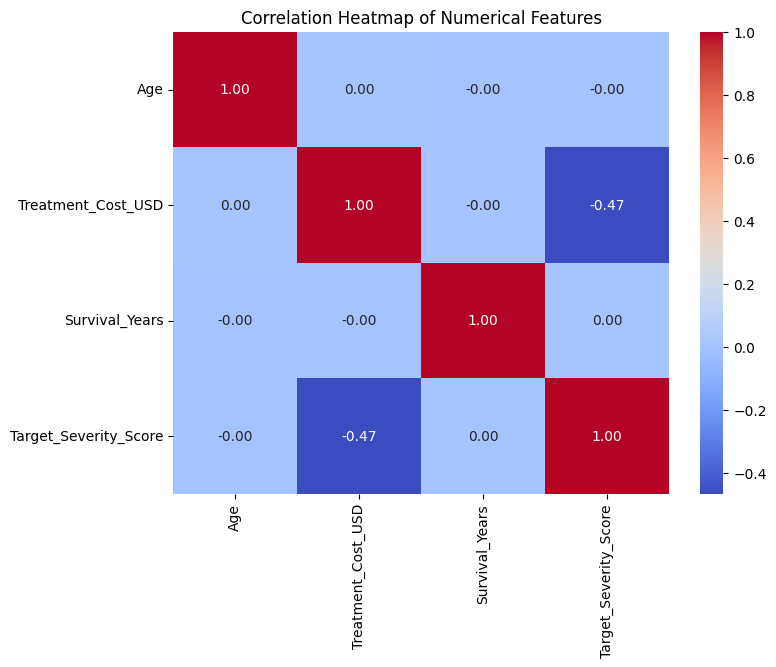

In [23]:
# Correlation heatmap for numerical features
corr = df[['Age', 'Treatment_Cost_USD', 'Survival_Years', 'Target_Severity_Score']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


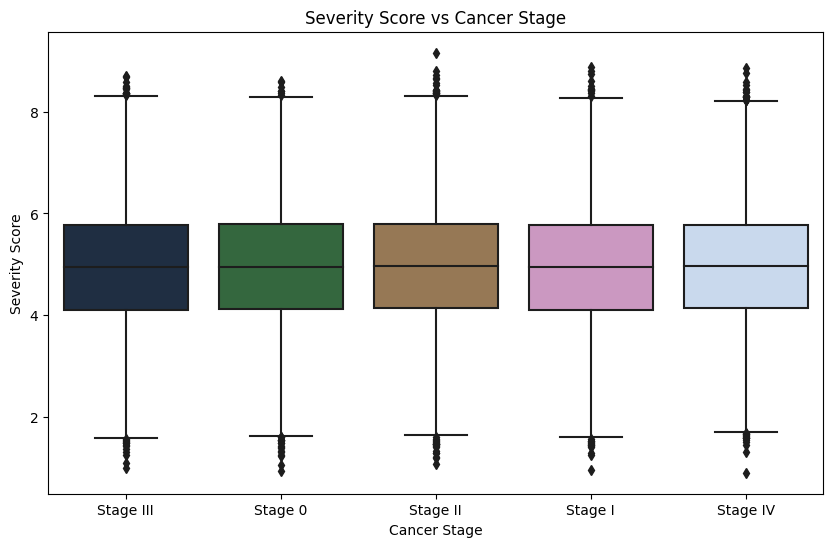

In [24]:
# Boxplot for Severity Score vs Cancer Stage
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cancer_Stage', y='Target_Severity_Score', data=df, palette='cubehelix')
plt.title('Severity Score vs Cancer Stage')
plt.xlabel('Cancer Stage')
plt.ylabel('Severity Score')
plt.show()


## Predictive modeling

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [26]:
# Define features and target
target = 'Target_Severity_Score'
features = ['Age', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Treatment_Cost_USD']

# Additionally, we include categorical features
categorical_features = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']

# We'll combine numeric features and categorical features in our processing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features),  # Pass-through numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-Hot Encode categorical features
    ]
)

# Label encode the target (if necessary) for classification algorithms
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# Split the data into training and testing sets
X = df[features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Classifier': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

In [27]:
# Iterate over classifiers, fit them, and evaluate
for name, clf in classifiers.items():
    # Create the pipeline for each classifier
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    # Step 1: Fit the model on the training data
    model.fit(X_train, y_train)

    # Step 2: Predict on the test set
    y_pred = model.predict(X_test)

    # Step 3: Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n{name} Accuracy: {accuracy * 100:.2f}%')

    # Step 4: Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f'Confusion Matrix for {name}:\n{cm}')

    # Step 5: Classification report
    report = classification_report(y_test, y_pred)
    print(f'Classification Report for {name}:\n{report}')


Logistic Regression Accuracy: 0.35%
Confusion Matrix for Logistic Regression:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          21       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         1
          24       0.00      0.00      0.00         1
          29       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         2
          34       0.00      0.00      0.00         2
          37       0.00      0.00      0.00        

## Thank you..pls upvote!!!!